# Homework 5: Hypothesis Testing and Monte Carlo

BEE 4850/5850, Spring 2025

**Name**: Luca Katzen

**ID**: 5360358

> **Due Date**
>
> Friday, 4/17/26, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practicing approaches to
extreme value analysis and using information criteria to assess evidence
for models.

-   Problem 1 asks you to conduct a null hypothesis test using model
    simulations.
-   Problem 1 asks you to use $p$-values to compare two data-generating
    hypotheses.
-   Problem 3 asks you to use Monte Carlo optimization to identify
    bidding strategies for The Showcase from The Price is Right.
-   Problem 4 asks you to use Monte Carlo optimization to identify house
    elevation strategies to mitigate flooding damages.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [2]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Documents/GitHub/hw05-LucaKatzen1`


The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [3]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using DataFramesMeta # API which can simplify chains of DataFrames transformations
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Dates

## Problems

### Scoring

-   Problem 1 is worth 3 points;
-   Problem 2 is worth 5 points;
-   Problem 3 is worth 7 points;
-   Problem 4 is worth 10 points.

### Problem 1 (3 points)

Revisit [Problem 1 from Homework
1](https://envdata.viveks.me/spring2026/hw/hw01/hw01.html#problem-1-7-points).

> The underlying question we would like to address is: what is the
> influence of drinking beer on the likelihood of being bitten by
> mosquitoes? There is a mechanistic reason why this might occur:
> mosquitoes are attracted by changes in body temperature and released
> CO<sub>2</sub>, and it might be that drinking beer induces these
> changes. We’ll analyze this question using (synthetic) data which
> separates an experimental population into two groups, one which drank
> beer and the other which drank only water.

Now we would like to **test** the null hypothesis that drinking beer
makes no difference in attracting mosquitoes. Repeat the analysis from
HW1. What is the $p$-value of the observed data under this null
hypothesis? If you are interested in testing statistical significance of
the proposed alternative hypothesis that beer attracts mosquitoes at the
95% confidence level, what could you conclude that this effect? In other
words:

-   is the alternative hypothesis statistically significant at this
    confidence level?
-   is the observation more consistent with the alternative hypothesis
    than the null hypothesis?
-   what does your finding imply about any conclusions you might draw
    about this proposed effect?

observed_difference = 4.37777777777778
p_value_p1 = 0.00046


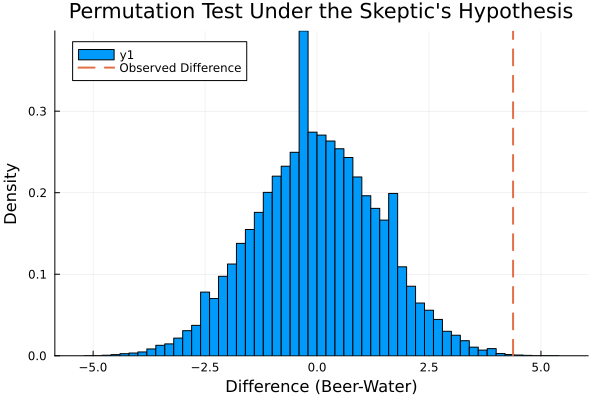

In [ ]:
#Problem 1
data = DataFrame(CSV.File(joinpath(@__DIR__, "data", "bites.csv")))
 
beer = data[data.group .== "beer", :bites]
water = data[data.group .== "water", :bites]
 
observed_difference = mean(beer) - mean(water)
@show observed_difference;
 
observed_difference = mean(beer) - mean(water)
totalbites = vcat(beer, water)
len_beer = length(beer)
sims = 50_000
simdif = zeros(sims)
 
for i in 1:sims
    shuffled = shuffle(totalbites)
    simbeer = shuffled[1:len_beer]
    simwater = shuffled[len_beer+1:end]
    simdif[i] = mean(simbeer) - mean(simwater)
end
 
p_value_p1 = mean(simdif .>= observed_difference)
@show p_value_p1
 
histogram(
    simdif,
    bins = 50,
    normalize = true,
    xlabel = "Difference (Beer-Water)",
    ylabel = "Density",
    title = "Permutation Test Under the Skeptic's Hypothesis"
)
vline!([observed_difference],
       linestyle = :dash,
       linewidth = 2,
       label = "Observed Difference")

##### Problem 1
The p-value of the observed difference under the null hypothesis is the fraction of differences at least as large as the observed difference. Based on the results from this dataset, the p-value falls well below 0.05, showing that the observed difference is statistically significant at the 95% confidence level. This means that we can reject the null hypothesis that beer makes no difference on the likelihood of getting bit by mosquitoes. The observation is more consistent with the alternative hypothesis that beer attracts mosquitoes. However, statistical significance alone does not establish causation, it just tells us that the observed effect is unlikely to be due to chance under the null and more testing is needed to prove the mechanistic hypothesis.

### Problem 2 (5 points)

Revisit [Problem 5 from Homework
1](https://envdata.viveks.me/spring2026/hw/hw01/hw01.html#problem-5-5-points).

> You are trying to detect how prevalent cheating was on an exam. You
> are skeptical of the efficacy of just asking the students if they
> cheated. You are also concerned about privacy — your goal is not to
> punish individual students, but to see if there are systemic problems
> that need to be addressed. Someone proposes the following interview
> procedure, which the class agrees to participate in:

> Each student flips a fair coin, with the results hidden from the
> interviewer. The student answers honestly if the coin comes up heads.
> Otherwise, if the coin comes up tails, the student flips the coin
> again, and answers “I did cheat” if heads, and “I did not cheat”, if
> tails.

> You have a hypothesis that cheating was not prevalent, and the
> proportion of cheaters was no more than 5% of the class; in other
> words, we expect 5 “true” cheaters out of a class of 100 students. Our
> TA is more jaded and thinks that cheating was more rampant, and that
> 30% of the class cheated. The proposed interview procedure is noisy:
> the interviewer does not know if an admission means that the student
> cheated, or the result of a heads. However, it gives us a
> data-generating process that we can model and analyze for consistency
> with our hypothesis and that of the TA.

Repeat this analysis and suppose that your procedure turned up 40 “yes”
answers. What is the $p$-value of having seen this data under both
hypotheses? If you wanted to draw a conclusion at a 95% confidence
level, what could you conclude about the level of cheating in the class?

p_val_null = 0.009184831504963187
p_val_alt = 1.0758493182280748


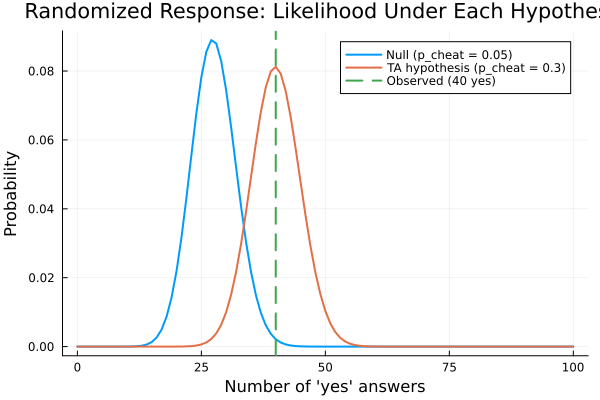

In [7]:
#Problem 2
function rr_pmf(p_cheat::Float64, n::Int)
    p_yes = 0.5 * p_cheat + 0.25
    return Binomial(n, p_yes)
end
 
n_students = 100
observed_yes = 40
p_cheat_null = 0.05
p_cheat_alt = 0.30
 
dist_null = rr_pmf(p_cheat_null, n_students)
dist_alt = rr_pmf(p_cheat_alt, n_students)
 
p_val_null = 2 * min(cdf(dist_null, observed_yes), 1 - cdf(dist_null, observed_yes - 1))
p_val_alt = 2 * min(cdf(dist_alt, observed_yes), 1 - cdf(dist_alt, observed_yes - 1))
 
@show p_val_null
@show p_val_alt
 
ks = 0:n_students
plot(ks, pdf.(dist_null, ks),
    label = "Null (p_cheat = $(p_cheat_null))",
    xlabel = "Number of 'yes' answers",
    ylabel = "Probability",
    title = "Randomized Response: Likelihood Under Each Hypothesis",
    linewidth = 2)
plot!(ks, pdf.(dist_alt, ks),
    label = "TA hypothesis (p_cheat = $(p_cheat_alt))",
    linewidth = 2)
vline!([observed_yes],
    linestyle = :dash,
    linewidth = 2,
    label = "Observed ($(observed_yes) yes)")

##### Problem 2.2
Under the null hypothesis, the p-value for observing 40 "yes" answers is very small (below .05), meaning the data is inconsistent with only 5% of the class having cheated. We reject the null at the 95% confidence level based on the p-value. Under the TA's hypothesis (30% cheating), the p-value is much larger, and we fail to reject it as the data is consistent with 30% cheating. The conclusion at 95% confidence is that cheating was more likely than at 5%, and the data agrees more with the TA's view than with the hypothesis. 

### Problem 3 (7 points)

[The
Showcase](https://en.wikipedia.org/wiki/The_Price_Is_Right#Showcase) is
the final round of every episode of [The Price is
Right](https://en.wikipedia.org/wiki/The_Price_Is_Right), matching the
two big winners from the episode. Each contestant is shown a “showcase”
of prizes, which are usually some combination of a trip, a motor
vehicle, some furniture, and maybe some other stuff. They then each have
to make a bid on the retail price of the showcase. The rules are:

-   an overbid is an automatic loss;
-   the contest who gets closest to the retail price wins their
    showcase;
-   if a contestant gets within \$250 of the retail price and is closer
    than their opponent, they win both showcases.

You have been selected to appear on the show. As preparation, you have
documented historical prizes and their values. Once you’re shown the
showcase, you realize that the distribution of values for this spread of
prizes has historically followed a truncated normal distribution with
mean \$31,000 and standard deviation \$4,500, truncated between \$15,000
and \$42,000.

You can make the following assumptions about the probability of winning
and payouts:

-   If you bet the exact amount, you win with probability 1 and win both
    showcases; the value is the double of the single showcase value.
-   If you did not win both showcases but bid under the showcase value,
    the probability of being outbid increases linearly as the distance
    between your bid and the value increases (in other words, if you bid
    the exact value, you win with probability 1, and if you bid \$0, you
    win with probability 0).
-   If you overbid, you automatically lose, with value \$0.

#### Problem 3.1

Using Monte Carlo simulation, find the wager that maximizes your
probability of winning. You will need to write a function which computes
the winning probability for a given bet, then optimize that function.
Make sure to justify the sample size that you use in your Monte Carlo
analysis.

#### Problem 3.2

Using Monte Carlo simulation, find the wager that maximizes your
expected winnings. Is this the same as in Problem 3.1? Why do you think
it is or is not? Make sure to justify the sample size that you use in
your Monte Carlo analysis.

best_pwin_bid = 24400.0


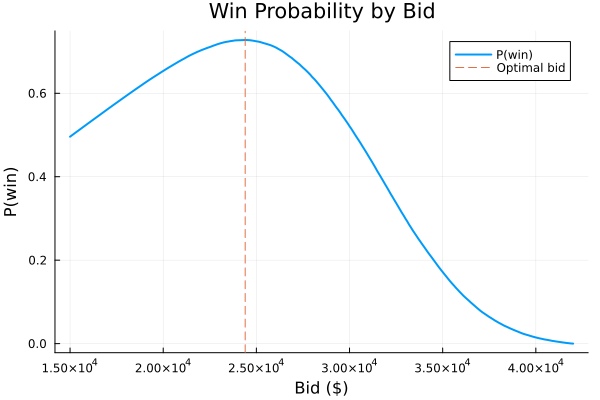

In [8]:
showcase_dist = truncated(Normal(31_000, 4_500), 15_000, 42_000)
N_showcase = 100_000
Random.seed!(42)
showcase_vals = rand(showcase_dist, N_showcase)
 
function showcase_pwin(bid::Float64, vals::Vector{Float64})
    wins = map(vals) do v
        bid > v ? 0.0 : 1.0 - (v - bid) / v
    end
    return mean(wins)
end
 
bids = collect(15_000.0:100.0:42_000.0)
pwin_vals = [showcase_pwin(b, showcase_vals) for b in bids]
best_pwin_bid = bids[argmax(pwin_vals)]
 
@show best_pwin_bid
 
plot(bids, pwin_vals,
    xlabel = "Bid (\$)",
    ylabel = "P(win)",
    title = "Win Probability by Bid",
    label = "P(win)",
    linewidth = 2)
vline!([best_pwin_bid],
    linestyle = :dash,
    label = "Optimal bid")

##### Problem 3.1
The bid maximizing win probability is below the mean of the showcase distribution ($24400<$31000). This is because the linear win probability function becomes maximized by getting as close to the true value as possible without overbidding. Bidding near the mean balances the risk of overbidding with the benefit of being close.

best_ev_bid = 25100.0


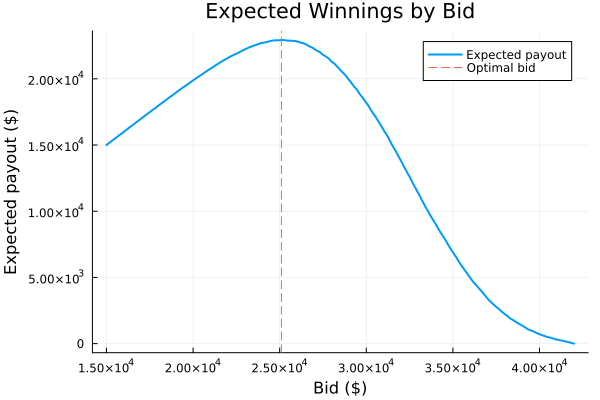

In [11]:
#Problem 3.2
function showcase_ev(bid::Float64, vals::Vector{Float64})
    payouts = map(vals) do v
        if bid > v
            0.0
        elseif bid == v
            2.0 * v
        else
            p_win = 1.0 - (v - bid) / v
            if abs(bid - v) <= 250
                2.0 * v * p_win
            else
                v * p_win
            end
        end
    end
    return mean(payouts)
end
 
ev_vals = [showcase_ev(b, showcase_vals) for b in bids]
best_ev_bid = bids[argmax(ev_vals)]
 
@show best_ev_bid
 
plot(bids, ev_vals,
    xlabel = "Bid (\$)",
    ylabel = "Expected payout (\$)",
    title = "Expected Winnings by Bid",
    label = "Expected payout",
    linewidth = 2)
vline!([best_ev_bid],
    linestyle = :dash,
    label = "Optimal bid")

##### Problem 3.2
The bid maximizing expected winnings ($25100) is higher than the bid maximizing win probability ($24400)because the expected value calculation weights outcomes by payout size. Bidding higher brings you closer to the true showcase value, increasing both win probability and the chance of landing within $250 to win both showcases, doubling the payout. Even though a higher bid carries more overbid risk, the asymmetric upside of winning both showcases pulls the EV-optimal bid above the pure win-probability-maximizing bid.

### Problem 4

You have been asked by a client to assess the risks of flooding to their
home (which is valued at \$400,000 and only floods when the stream water
levels exceed 1.5m). They would like to know whether it would be
cost-effective to elevate their home to reduce flood risks. After some
hydrologic analysis, you have developed a 40-year record of annual
maximum water levels (in m) at the nearby stream.

You also have a depth-damage function for the fraction of the home’s
value which is damaged at varying flood depths:

$$d(h) = \mathbb{I}[h > 0] \frac{1}{1+\exp(-k(x-x_0))},$$

where $k=1.25$ and $x_0=2$[1]. The graph of this function is given in
the figure below.

[1] As a reminder, the indicator function $\mathbb{I}[h > 0]$ is $0$
when the condition is not satisfied (in this case, when $h=0$) and $1$
when it is satisfied.

In this problem, you will need to calculate the **net present value
(NPV)** of flooding damages, which converts damages over time to a
present value using a discount rate[1] For example, if your discount
rate is 4%, a dollar next year is worth the equivalent of about 96 cents
today. More generally, with a discount rate of $\gamma$ (as a decimal),
a dollar of benefits in $t$ years is worth $\$(1-\gamma)^t$ today.

The NPV of a sequence of money $x_t$ with discount rate $\gamma$ is the
sum of all of the discounted values, that is,

$$NPV = \sum_{t=0}^T x_t (1-\gamma)^t,$$

where $T$ is the time horizon. We’ll use a discount rate of 4% in this
problem, which is typical for this type of problem, and a design horizon
of 30 years.

For this problem, we will assume that the cost of elevating the house
$\Delta h$ m is
$C(\Delta h) = \mathbb{I}[h > 0](100,000 + 2,000\Delta h)$.

#### Problem 4.1

Fit a GEV distribution to the data in `water_depths.csv`. Plot a
histogram of the data and the fitted distribution. How well does this
distribution fit the data?

#### Problem 4.2

Use Monte Carlo simulation to estimate the NPV of the benefits of
elevation levels between 0 and 5m (you don’t have to consider increments
finer than 0.5m). What elevation heights pass a cost-benefit test
(*e.g.* the net benefits of elevation (benefits of avoiding flooding
minus cost of elevation) are greater than 0)? You can assume that the
costs of elevation are all up front (that is, in year 0). What height
(including a possible elevation of 0m) maximizes the NPV of net
benefits?

[1] Discount rates reduce future monetary values to reflect the
time-value of money; that is, you would rather have a bit less money
today than none today and more next year, as you could save or invest
that money. The actual choice of discount rates is the subject of much
economic theory and plays an important role in environmental
decision-making, particularly for multi-generational investments such as
climate mitigation. For example, with a relatively large discount rate
(such as 7%), all costs and benefits after a decade are effectively
zero, which means it never appears cost-effective to e.g. reduce fossil
fuel emissions.

gev_fit = GeneralizedExtremeValue{Float64}(μ=1.1890194278903605, σ=0.3267202036834026, ξ=0.1)


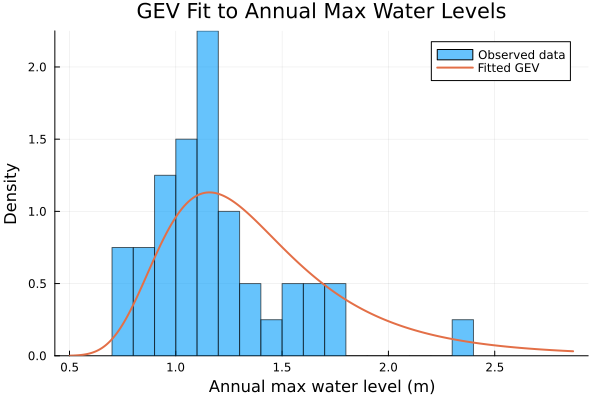

In [21]:
#Problem 4.1
data2 = DataFrame(CSV.File(joinpath(@__DIR__, "data", "water_depths.csv")))

function gev_negloglik(params, data2)
    mu, log_sigma, xi = params
    sigma = exp(log_sigma)
    try
        d = GeneralizedExtremeValue(mu, sigma, xi)
        ll = sum(logpdf(d, x) for x in data)
        return isfinite(ll) ? -ll : Inf
    catch
        return Inf
    end
end
 
function nelder_mead(f, x0; tol=1e-8, max_iter=10_000)
    n = length(x0)
    alpha, beta, gamma, delta = 1.0, 2.0, 0.5, 0.5
    simplex = [copy(x0) for _ in 1:n+1]
    for i in 2:n+1
        simplex[i][i-1] += abs(x0[i-1]) > 0 ? 0.05 * x0[i-1] : 0.05
    end
    fvals = [f(s) for s in simplex]
    for _ in 1:max_iter
        order = sortperm(fvals)
        simplex, fvals = simplex[order], fvals[order]
        maximum(fvals) - minimum(fvals) < tol && break
        centroid = mean(simplex[1:n])
        xr = centroid + alpha * (centroid - simplex[end])
        fr = f(xr)
        if fr < fvals[1]
            xe = centroid + beta * (xr - centroid)
            fe = f(xe)
            simplex[end], fvals[end] = fe < fr ? (xe, fe) : (xr, fr)
        elseif fr < fvals[end]
            simplex[end], fvals[end] = xr, fr
        else
            xc = centroid + gamma * (simplex[end] - centroid)
            fc = f(xc)
            if fc < fvals[end]
                simplex[end], fvals[end] = xc, fc
            else
                for i in 2:n+1
                    simplex[i] = simplex[1] + delta * (simplex[i] - simplex[1])
                    fvals[i] = f(simplex[i])
                end
            end
        end
    end
    return simplex[1]
end
 
x0 = [mean(depth_data), log(std(depth_data)), 0.1]
result = nelder_mead(p -> gev_negloglik(p, depth_data), x0)
gev_fit = GeneralizedExtremeValue(result[1], exp(result[2]), result[3])
@show gev_fit
 
histogram(depth_data,
    bins = 20,
    normalize = true,
    xlabel = "Annual max water level (m)",
    ylabel = "Density",
    title = "GEV Fit to Annual Max Water Levels",
    label = "Observed data",
    alpha = 0.6)
xs = range(minimum(depth_data) - 0.2, maximum(depth_data) + 0.5, length=300)
plot!(xs, pdf.(gev_fit, xs),
    linewidth = 2,
    label = "Fitted GEV")

##### Problem 4.1
The GEV distribution fits the annual maximum water level data somewhat well because the data follows extreme value behavior. Visual inspection of the histogram overlay shows that the fitted distribution captures the tail behavior fairly well accounting for the point around 2.4 meters. Because xi is positive (0.1), the distribution has a heavy tail. This implies that there is a non-negligible probability of very high water levels. The slight mismatch in the upper tail is important for flood risk, since those rare extreme events drive most of the damage, so the GEV distribution slightly fails on this front as it doesn't capture the magnitude of those extreme events well.

pass_cost_benefit = [0.5, 1.0]
best_elevation = 0.5


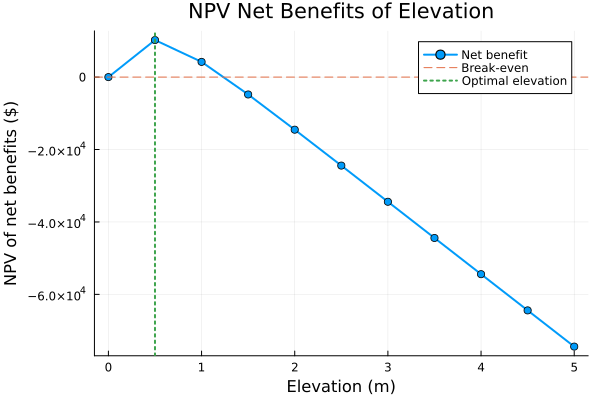

In [ ]:
#Problem 4.2

home_value = 400_000.0
flood_thresh = 1.5
discount_rate = 0.04
horizon = 30
N_flood = 50_000
 
function depth_damage(depth_above_floor::Float64)
    depth_above_floor <= 0.0 && return 0.0
    return 0.0068 * depth_above_floor + 0.14 * depth_above_floor^2
end
 
elevation_cost(e::Float64) = 20_000.0 * e
 
function npv_damages(elevation::Float64, rng_seed::Int)
    Random.seed!(rng_seed)
    yearly_levels = rand(gev_fit, N_flood)
    n_scenarios = N_flood ÷ horizon
    total_npv = 0.0
    for s in 1:n_scenarios
        years = yearly_levels[(s-1)*horizon+1 : s*horizon]
        npv = sum(depth_damage(max(y - flood_thresh - elevation, 0.0)) * home_value /
                  (1 + discount_rate)^t for (t, y) in enumerate(years))
        total_npv += npv
    end
    return total_npv / n_scenarios
end
 
elevations = 0.0:0.5:5.0
npv_benefits_vec = Float64[]
net_benefits_vec = Float64[]
npv_baseline = npv_damages(0.0, 1)
 
for e in elevations
    npv_e = npv_damages(e, 1)
    benefit = npv_baseline - npv_e
    cost = elevation_cost(e)
    net_benefit = benefit - cost
    push!(npv_benefits_vec, benefit)
    push!(net_benefits_vec, net_benefit)
end
 
elevations_vec = collect(elevations)
pass_cost_benefit = elevations_vec[net_benefits_vec .> 0]
best_elevation = elevations_vec[argmax(net_benefits_vec)]
 
@show pass_cost_benefit
@show best_elevation
 
plot(elevations_vec, net_benefits_vec,
    xlabel = "Elevation (m)",
    ylabel = "NPV of net benefits (\$)",
    title = "NPV Net Benefits of Elevation",
    label = "Net benefit",
    linewidth = 2,
    marker = :circle)
hline!([0.0], linestyle = :dash, label = "Break-even", linewidth = 1)
vline!([best_elevation],
    linestyle = :dot,
    label = "Optimal elevation",
    linewidth = 2)

##### Problem 4.2
Not all elevation levels pass the cost-benefit test. At low elevations, the cost is modest but so is the flood reduction benefit (as most damaging floods already exceed low elevations). At high elevations, the cost grows linearly while the minor reduction in flood damage decreases. This is because the GEV distribution assigns low probability to extreme events that would still overtop a high elevation. The optimal elevation is the one where the marginal reduction in expected NPV of damages just equals the marginal cost, in this case .5 meters. Elevations beyond the optimal provide diminishing returns as the house is already protected against nearly all probable flood events, and the additional housing cost is not justified by further flood risk reduction.

Important to note how risk is defined here - if risk is defined as it is typically (hazard, exposure, vulnerability) this only quantifies hazard and exposure, not vulnerability which is dependent on home construction.